In [ ]:
import os
import datetime
import warnings
import numpy as np
import pandas as pd
import rasterio as rio
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import tv_tensors
from torchvision.models import resnet34, ResNet34_Weights
import segmentation_models_pytorch as smp
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score
from accelerate import Accelerator, notebook_launcher

from IPython.display import clear_output

from src.datasets import CloudDataset
from src.models import UNetPlusPlusResNet34

warnings.filterwarnings("ignore")

In [ ]:
DATA = "../input/datasets/toasunzce/cloud-segmentation/data"
EPOCHS = 20
BATCH = 16  # per process;
            # effective batch 16 * 2 = 32
subdir = datetime.datetime.now().strftime("%d_%m_%Y-%H_%M")
WEIGHTS_DIR = "/kaggle/working/cloud_weights/" + subdir
os.makedirs(WEIGHTS_DIR, exist_ok=True)

CLASS_NAMES = ["clear", "thick", "thin", "shadow"]
CMAP = ListedColormap(["black", "red", "orange", "gray"])

In [ ]:
import math

class CosineAnnealingWarmRestartsDecay(torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
    def __init__(self, optimizer, T_0, T_mult=1, eta_min=0, last_epoch=-1, decay=1):
        super().__init__(optimizer, T_0, T_mult=T_mult,
                         eta_min=eta_min, last_epoch=last_epoch)
        self.decay = decay
        self.initial_lrs = self.base_lrs[:]
        self.initial_eta_min = eta_min

    def step(self, epoch=None):
        if epoch is None:
            if self.T_cur + 1 == self.T_i:
                self.base_lrs = [lr * self.decay for lr in self.base_lrs]
                self.eta_min  = self.eta_min * self.decay
        else:
            if epoch < 0:
                raise ValueError(f"Expected non-negative epoch, but got {epoch}")
            if epoch >= self.T_0:
                if self.T_mult == 1:
                    n = int(epoch / self.T_0)
                else:
                    n = int(math.log((epoch / self.T_0 * (self.T_mult - 1) + 1), self.T_mult))
            else:
                n = 0
            self.base_lrs = [lr * (self.decay ** n) for lr in self.initial_lrs]
            self.eta_min  = self.initial_eta_min * (self.decay ** n)
        super().step(epoch)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

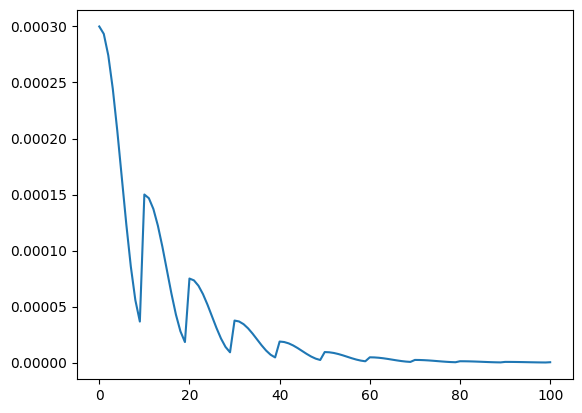

In [ ]:
model = UNetPlusPlusResNet34(
    in_channels=7,
    num_classes=4,
    pretrained="imagenet",
)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = CosineAnnealingWarmRestartsDecay(
    optimizer,
    T_0=10,
    T_mult=1,
    eta_min=3e-5,
    decay=0.5,
)

temp = []
temp.append(optimizer.param_groups[0]['lr'])
for i in range(100):
    scheduler.step()
    temp.append(optimizer.param_groups[0]['lr'])

plt.plot(temp)

In [8]:
def compute_class_weights(data_dir, num_classes=4):
    meta = pd.read_csv(os.path.join(data_dir, "metadata.csv"))
    train = meta[meta["split"] == "train"]
    
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, row in tqdm.tqdm(train.iterrows(), total=len(train)):
        with rio.open(os.path.join(data_dir, row["label"])) as src:
            mask = src.read(1)
        for c in range(num_classes):
            counts[c] += (mask == c).sum()
    
    freq = counts / counts.sum()
    median_freq = np.median(freq)
    weights = median_freq / freq
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)

w = compute_class_weights(DATA)
print(dict(zip(CLASS_NAMES, w.tolist())))

100%|██████████| 7951/7951 [01:20<00:00, 98.23it/s] 

{'clear': 0.2692376375198364, 'thick': 0.5410593748092651, 'thin': 1.556660771369934, 'shadow': 1.6330422163009644}


In [8]:
def plot_history(hist, epoch):
    
    epochs = range(1, len(hist["loss"]) + 1)
    
    iou = np.array(hist["iou"])
    dice = np.array(hist["dice"])
    losses = np.array(hist["loss"])
    lrs = np.array(hist["lr"])

    # figure setup
    fig = plt.figure(figsize=(8, 12), layout="constrained")
    spec = fig.add_gridspec(4, 3)

    ax0a = fig.add_subplot(spec[0, :2])
    ax0b = fig.add_subplot(spec[0, 2])

    ax1a = fig.add_subplot(spec[1, :2])
    ax1b = fig.add_subplot(spec[1, 2])

    ax2 = fig.add_subplot(spec[2, :])
    ax3 = fig.add_subplot(spec[3, :])

    # iou
    ax0a.plot(epochs, iou.mean(axis=1), "k--", label="mIoU")
    ax0a.set_title("val IoU per class")
    ax0a.set_xlabel("epoch")
    ax0a.set_ylim(0, 1)
    ax0a.grid(True)

    ax0b.plot(epochs[-5:], iou.mean(axis=1)[-5:], "k--")
    ax0b.set_title("TRUNC val IoU per class")
    ax0b.set_xlabel("epoch")
    ax0b.set_ylim(0, 1)
    ax0b.grid(True)
    if len(epochs) >= 3:
        ax0b.axvline(x=epochs[-3], color='red', linestyle='dotted')

    for c, name in enumerate(CLASS_NAMES):
        ax0a.plot(epochs, iou[:, c], label=name)
        ax0b.plot(epochs[-5:], iou[:, c][-5:])
    
    ax0a.legend(loc="lower right")
    
    # dice
    ax1a.plot(epochs, dice.mean(axis=1), "k--", label="mDice")
    ax1a.set_title("val Dice per class")
    ax1a.set_xlabel("epoch")
    ax1a.set_ylim(0, 1)
    ax1a.grid(True)

    ax1b.plot(epochs[-5:], dice.mean(axis=1)[-5:], "k--")
    ax1b.set_title("TRUNC val Dice per class")
    ax1b.set_xlabel("epoch")
    ax1b.set_ylim(0, 1)
    ax1b.grid(True)
    if len(epochs) >= 3:
        ax1b.axvline(x=epochs[-3], color='red', linestyle='dotted')

    for c, name in enumerate(CLASS_NAMES):
        ax1a.plot(epochs, dice[:, c], label=name)
        ax1b.plot(epochs[-5:], dice[:, c][-5:])
    
    ax1a.legend(loc="lower right")
        
    # loss
    ax2.plot(epochs, losses, color="tab:blue")
    ax2.set_title("train loss")
    ax2.set_xlabel("epoch")
    ax2.grid(True)

    # lr
    ax3.plot(epochs, lrs, color="tab:red")
    ax3.set_title("learning_rate")
    ax3.set_xlabel("epoch")
    ax3.grid(True)
    
    plt.savefig(os.path.join(WEIGHTS_DIR, "convergence.png"))
    plt.show()
    plt.close(fig)

In [ ]:
def train_fn():
    accelerator = Accelerator(mixed_precision="fp16")

    train_ds = CloudDataset(DATA, "train")
    valid_ds = CloudDataset(DATA, "val")
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

    with accelerator.main_process_first():
        model = UNetPlusPlusResNet34(
            in_channels=7,
            num_classes=4,
            pretrained="imagenet",
        )

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    scheduler = CosineAnnealingWarmRestartsDecay(
        optimizer, T_0=10, T_mult=1, eta_min=3e-5, decay=0.5
    )

    w = torch.tensor([0.279, 0.541, 1.556, 1.633], device=accelerator.device)
    ce = nn.CrossEntropyLoss(weight=w)
    lovasz = smp.losses.LovaszLoss(mode="multiclass", per_image=False)

    iou_metric  = MulticlassJaccardIndex(num_classes=4, average=None).to(accelerator.device)
    dice_metric = MulticlassF1Score(num_classes=4, average=None).to(accelerator.device)

    model, optimizer, train_loader, val_loader = accelerator.prepare(
        model, optimizer, train_loader, val_loader
    )

    hist = {"loss": [], "iou": [], "dice": [], "lr": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for x, y in tqdm.tqdm(train_loader, disable=not accelerator.is_local_main_process):
            optimizer.zero_grad()
            logits = model(x)
            loss = ce(logits, y) + 0.5 * lovasz(logits, y)
            accelerator.backward(loss)
            optimizer.step()
            running += loss.item()
        train_loss = running / len(train_loader)

        model.eval()
        iou_metric.reset(); dice_metric.reset()
        with torch.no_grad():
            for x, y in val_loader:
                preds = model(x).argmax(dim=1)
                preds, y = accelerator.gather_for_metrics((preds, y))
                iou_metric.update(preds, y)
                dice_metric.update(preds, y)
        iou = iou_metric.compute()
        dsc = dice_metric.compute()
        miou, mdice = iou.mean().item(), dsc.mean().item()

        scheduler.step()

        if accelerator.is_main_process:
            clear_output(wait=True)
            print(f"epoch {epoch}: loss={train_loss:.3f}  mIoU={miou:.3f}  mDice={mdice:.3f}")
            for c, name in enumerate(CLASS_NAMES):
                print(f"  {name:7s} IoU={iou[c]:.3f}  Dice={dsc[c]:.3f}")
            print(f"lr: {optimizer.param_groups[0]['lr']}")
            hist["loss"].append(train_loss)
            hist["iou"].append(iou.tolist())
            hist["dice"].append(dsc.tolist())
            hist["lr"].append(optimizer.param_groups[0]['lr'])
            unwrapped_model = accelerator.unwrap_model(model)
            accelerator.save(unwrapped_model.state_dict(),
                              os.path.join(WEIGHTS_DIR, f"epoch_{epoch:02d}.pt"))
            plot_history(hist, epoch)

epoch 15: loss=0.519  mIoU=0.705  mDice=0.820
  clear   IoU=0.854  Dice=0.921
  thick   IoU=0.822  Dice=0.902
  thin    IoU=0.569  Dice=0.725
  shadow  IoU=0.574  Dice=0.729
lr: 8.249999999999999e-05


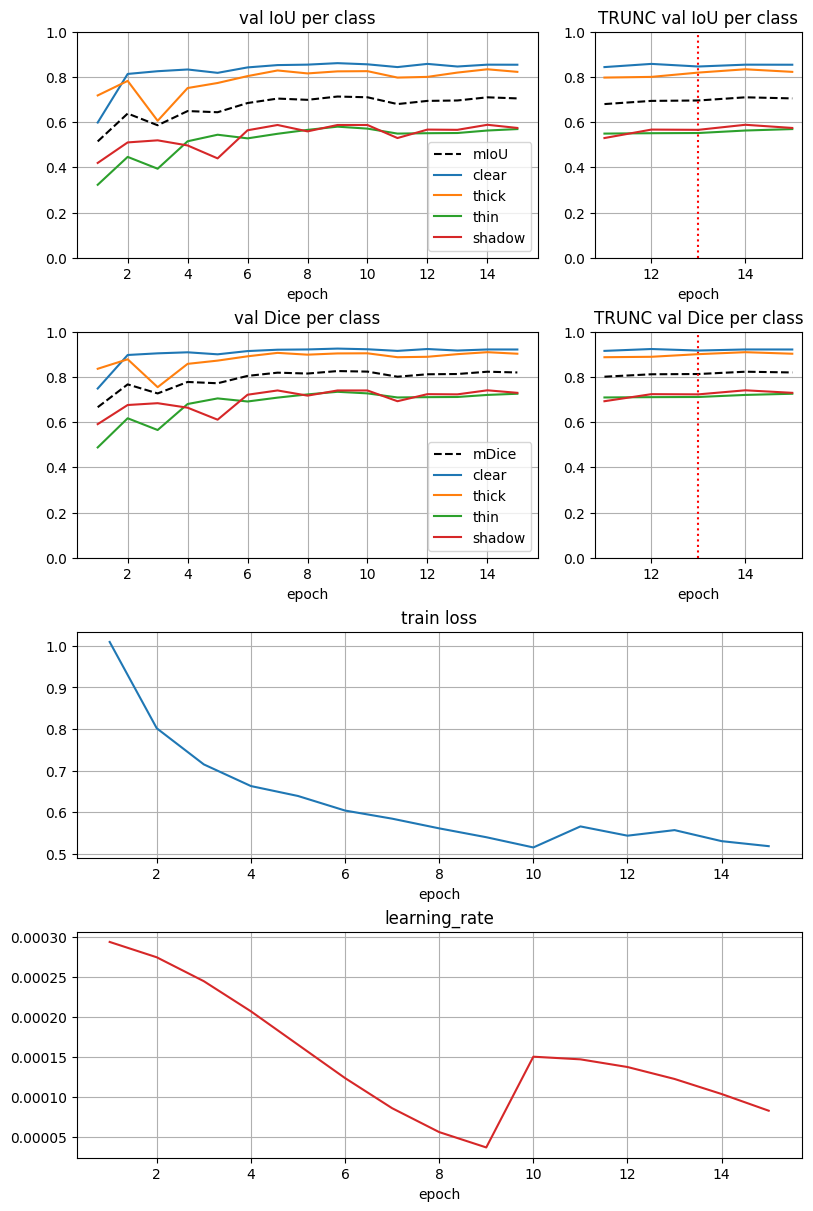

 91%|█████████ | 226/249 [05:03<00:31,  1.36s/it]

In [ ]:
notebook_launcher(train_fn, num_processes=2)